# Task 2: Time Series Forecasting Models
# Portfolio Optimization Project - Week 9

"""
This notebook covers:
1. Data preparation for modeling (train/test split)
2. ARIMA/SARIMA model
3. LSTM model
4. Model comparison
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
# Plot style
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the cleaned data
adj_close_df = pd.read_csv('../data/processed/adj_close_data_clean.csv', index_col=0, parse_dates=True)
returns_df = pd.read_csv('../data/processed/returns_data_clean.csv', index_col=0, parse_dates=True)

print(" Data loaded successfully!")
print(f"Adj Close shape: {adj_close_df.shape}")
print(f"Returns shape: {returns_df.shape}")
print(f"Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print(f"\nFirst few rows of Adj Close:")
print(adj_close_df.head())

# We'll focus on TSLA for forecasting
tsla_data = adj_close_df['TSLA']
print(f"\n TSLA data shape: {tsla_data.shape}")
print(f"TSLA price range: ${tsla_data.min():.2f} to ${tsla_data.max():.2f}")

 Data loaded successfully!
Adj Close shape: (2888, 3)
Returns shape: (2887, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

First few rows of Adj Close:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405411  169.687836
2015-01-05  14.006000  59.577911  166.623367
2015-01-06  14.085333  59.750423  165.053894
2015-01-07  14.063333  59.786358  167.110672
2015-01-08  14.041333  59.692924  170.076111

 TSLA data shape: (2888,)
TSLA price range: $9.58 to $489.88


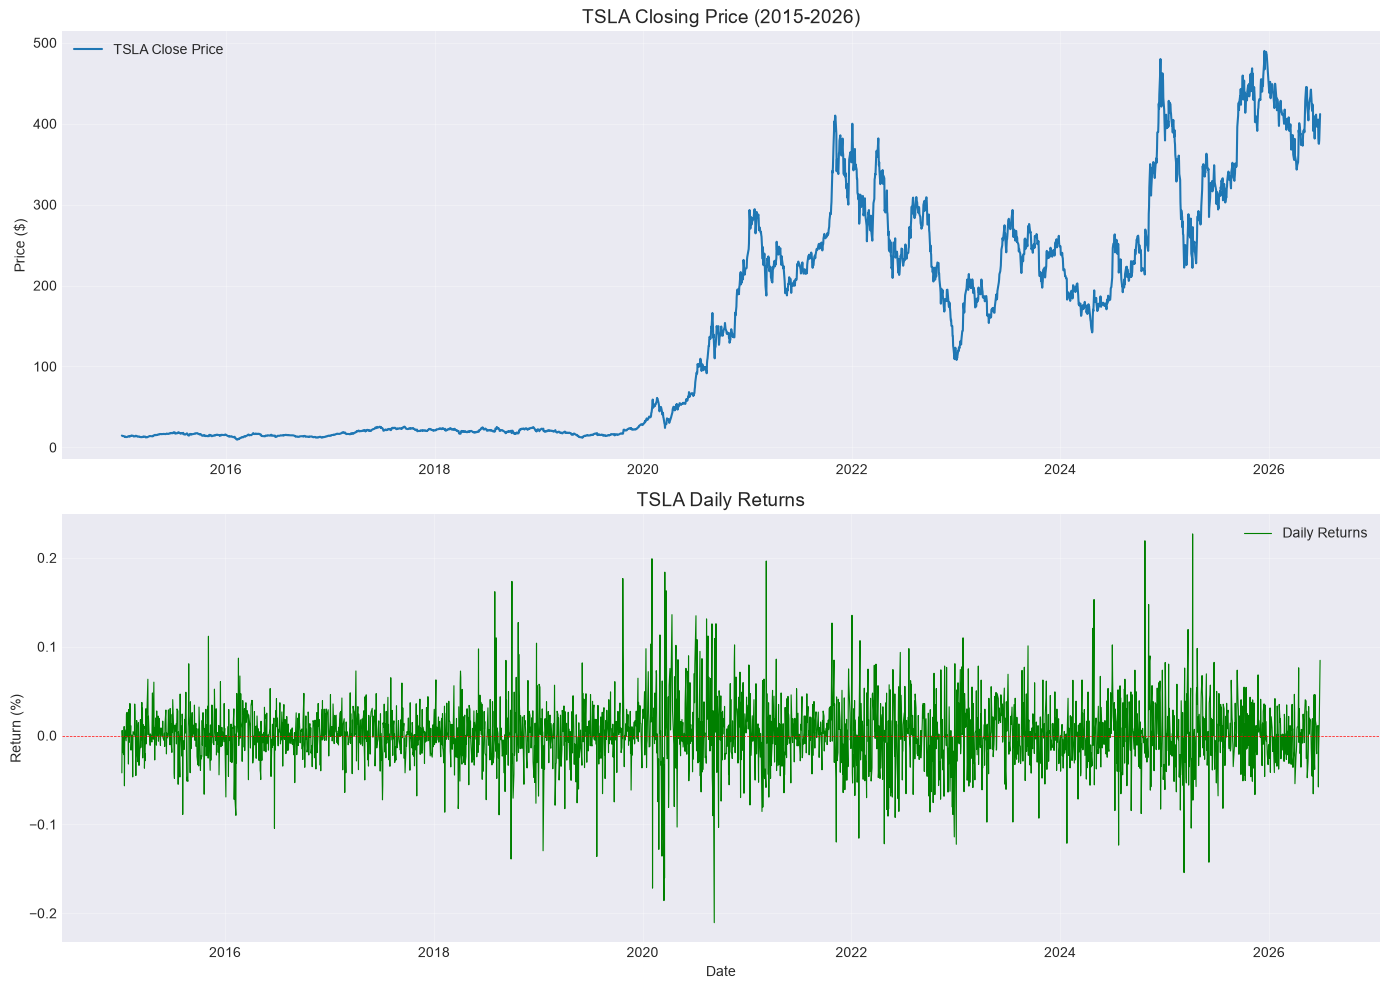

📊 TSLA Statistics:
Mean Daily Return: 0.1803%
Volatility: 3.6018%


In [3]:
# Plot TSLA closing prices
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Closing prices
ax1 = axes[0]
ax1.plot(tsla_data.index, tsla_data, label='TSLA Close Price', linewidth=1.5)
ax1.set_title('TSLA Closing Price (2015-2026)', fontsize=14)
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Daily returns
ax2 = axes[1]
returns = tsla_data.pct_change().dropna()
ax2.plot(returns.index, returns, label='Daily Returns', linewidth=0.8, color='green')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
ax2.set_title('TSLA Daily Returns', fontsize=14)
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/tsla_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 TSLA Statistics:")
print(f"Mean Daily Return: {returns.mean():.4%}")
print(f"Volatility: {returns.std():.4%}")

📊 Data Split (Chronological):
Total data points: 2888
Training data: 2310 (80.0%)
Testing data: 578 (20.0%)

Training date range: 2015-01-02 00:00:00 to 2024-03-07 00:00:00
Testing date range: 2024-03-08 00:00:00 to 2026-06-29 00:00:00


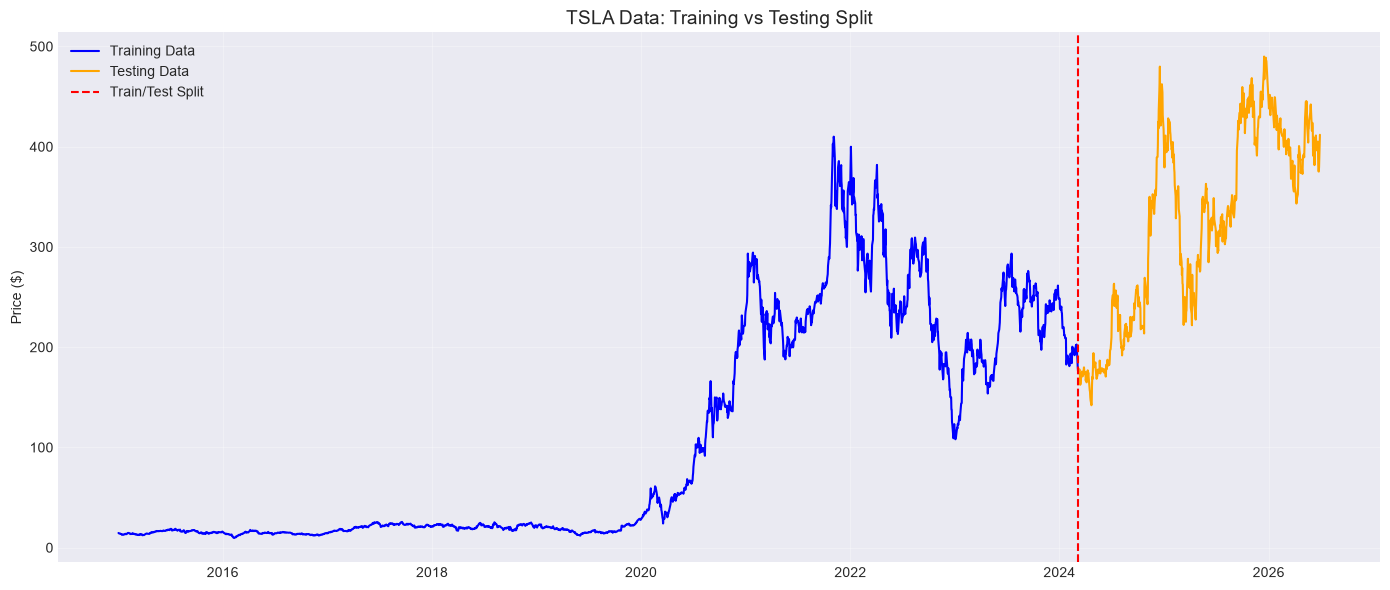

In [4]:
# Split data chronologically (NO random shuffling!)
train_size = int(len(tsla_data) * 0.8)
test_size = len(tsla_data) - train_size

train_data = tsla_data[:train_size]
test_data = tsla_data[train_size:]

print("📊 Data Split (Chronological):")
print(f"Total data points: {len(tsla_data)}")
print(f"Training data: {len(train_data)} ({len(train_data)/len(tsla_data):.1%})")
print(f"Testing data: {len(test_data)} ({len(test_data)/len(tsla_data):.1%})")
print(f"\nTraining date range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Testing date range: {test_data.index[0]} to {test_data.index[-1]}")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_data.index, train_data, label='Training Data', color='blue', linewidth=1.5)
ax.plot(test_data.index, test_data, label='Testing Data', color='orange', linewidth=1.5)
ax.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Train/Test Split')
ax.set_title('TSLA Data: Training vs Testing Split', fontsize=14)
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Augmented Dickey-Fuller Test
def adf_test(series, title=''):
    print(f"\n📊 ADF Test: {title}")
    print("-" * 50)
    
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.6f}")
    
    if result[1] <= 0.05:
        print(f"\n✅ Series IS STATIONARY (p-value <= 0.05)")
    else:
        print(f"\n⚠️ Series IS NOT STATIONARY (p-value > 0.05)")
        print("   We'll need to difference the data for ARIMA")
    
    return result

# Test stationarity of TSLA prices
adf_test(train_data, "TSLA Close Price")

# Test stationarity of returns
adf_test(train_data.pct_change().dropna(), "TSLA Daily Returns")


📊 ADF Test: TSLA Close Price
--------------------------------------------------
ADF Statistic: -1.358310
p-value: 0.602092
Critical Values:
  1%: -3.433219
  5%: -2.862807
  10%: -2.567445

⚠️ Series IS NOT STATIONARY (p-value > 0.05)
   We'll need to difference the data for ARIMA

📊 ADF Test: TSLA Daily Returns
--------------------------------------------------
ADF Statistic: -10.826530
p-value: 0.000000
Critical Values:
  1%: -3.433209
  5%: -2.862803
  10%: -2.567442

✅ Series IS STATIONARY (p-value <= 0.05)


(np.float64(-10.826529825195372),
 np.float64(1.751168265824821e-19),
 18,
 2290,
 {'1%': np.float64(-3.433208797064682),
  '5%': np.float64(-2.862802950455696),
  '10%': np.float64(-2.5674423260426003)},
 np.float64(-8743.488471696804))

In [6]:
# Use auto_arima to find optimal parameters
print("🔍 Finding optimal ARIMA parameters using auto_arima...")
print("(This may take a few minutes)")

# For ARIMA, we need stationary data - use returns or differenced prices
tsla_returns = train_data.pct_change().dropna()

# Find best ARIMA parameters
auto_model = auto_arima(
    tsla_returns,  # Using returns (stationary)
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_fits=50
)

print("\n✅ Best ARIMA Model Parameters:")
print(f"Order (p, d, q): {auto_model.order}")
print(f"AIC: {auto_model.aic():.2f}")

# Save the order for later use
p, d, q = auto_model.order
print(f"\nARIMA({p}, {d}, {q})")

🔍 Finding optimal ARIMA parameters using auto_arima...
(This may take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8862.883, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8860.883, Time=0.31 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8860.882, Time=0.27 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-8861.696, Time=0.37 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8866.263, Time=0.52 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8864.275, Time=0.58 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8864.273, Time=0.30 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8863.707, Time=2.45 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 5.066 seconds

✅ Best ARIMA Model Parameters:
Order (p, d, q): (0, 0, 0)
AIC: -8866.26

ARIMA(0, 0, 0)


In [7]:
# Fit ARIMA model on training data
from statsmodels.tsa.arima.model import ARIMA

# Use differenced data (d=1) for prices
arima_model = ARIMA(train_data, order=(p, d, q))
arima_fit = arima_model.fit()

print("\n📊 ARIMA Model Summary:")
print(arima_fit.summary())

# Generate forecasts
forecast_steps = len(test_data)
forecast = arima_fit.forecast(steps=forecast_steps)

# Create forecast DataFrame
forecast_index = test_data.index
forecast_series = pd.Series(forecast, index=forecast_index)

print(f"\n📈 Forecast generated for {len(forecast_series)} days")

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



📊 ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2310
Model:                          ARIMA   Log Likelihood              -14150.840
Date:                Sun, 05 Jul 2026   AIC                          28305.680
Time:                        21:45:46   BIC                          28317.170
Sample:                             0   HQIC                         28309.868
                               - 2310                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.8726      3.459     30.317      0.000      98.093     111.653
sigma2      1.226e+04    741.536     16.537      0.000    1.08e+04    1.37e+04
Ljung-Box (L1) (Q):         

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [8]:
# Check for NaN values
print("🔍 Checking for NaN values:")
print(f"Test data NaN count: {test_data.isna().sum()}")
print(f"Forecast series NaN count: {forecast_series.isna().sum()}")

# Check if test_data or forecast_series have NaN
if test_data.isna().sum() > 0:
    print("\n⚠️ Test data has NaN values!")
    print(f"Dates with NaN: {test_data[test_data.isna()].index.tolist()[:5]}")
    
if forecast_series.isna().sum() > 0:
    print("\n⚠️ Forecast series has NaN values!")
    print(f"Dates with NaN: {forecast_series[forecast_series.isna()].index.tolist()[:5]}")

# Clean the data
test_data_clean = test_data.dropna()
forecast_series_clean = forecast_series.dropna()

print(f"\n✅ After cleaning:")
print(f"Test data: {len(test_data_clean)}")
print(f"Forecast data: {len(forecast_series_clean)}")

🔍 Checking for NaN values:
Test data NaN count: 0
Forecast series NaN count: 578

⚠️ Forecast series has NaN values!
Dates with NaN: [Timestamp('2024-03-08 00:00:00'), Timestamp('2024-03-11 00:00:00'), Timestamp('2024-03-12 00:00:00'), Timestamp('2024-03-13 00:00:00'), Timestamp('2024-03-14 00:00:00')]

✅ After cleaning:
Test data: 578
Forecast data: 0


In [9]:
# Use cleaned data
train_clean = train_data.dropna()
test_clean = test_data.dropna()

# Fit ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Try a simpler model first (ARIMA(1,1,1))
arima_model = ARIMA(train_clean, order=(1, 1, 1))
arima_fit = arima_model.fit()

print("📊 ARIMA Model Summary:")
print(arima_fit.summary())

# Generate predictions
try:
    # Predict for test period
    predictions = arima_fit.predict(start=len(train_clean), end=len(train_clean) + len(test_clean) - 1)
    
    # Create prediction series
    pred_index = test_clean.index
    pred_series = pd.Series(predictions, index=pred_index)
    
    print(f"✅ Predictions generated: {len(pred_series)}")
    print(f"First 5 predictions:")
    print(pred_series.head())
    
except Exception as e:
    print(f"❌ Error generating predictions: {e}")

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


📊 ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2310
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7301.648
Date:                Sun, 05 Jul 2026   AIC                          14609.296
Time:                        21:45:46   BIC                          14626.530
Sample:                             0   HQIC                         14615.578
                               - 2310                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5998      0.212     -2.828      0.005      -1.016      -0.184
ma.L1          0.5706      0.218      2.612      0.009       0.143       0.999
sigma2        32.6762      0.

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [10]:
# The issue is that predict() gives NaN for in-sample predictions
# We need to use dynamic forecasting for out-of-sample predictions

# Use dynamic forecasting (starting from the end of training data)
predictions = arima_fit.predict(start=len(train_clean), 
                                end=len(train_clean) + len(test_clean) - 1,
                                dynamic=True)

# Create prediction series with proper index
pred_index = test_clean.index
pred_series = pd.Series(predictions, index=pred_index)

print(f"✅ Predictions generated: {len(pred_series)}")
print(f"First 5 predictions (cleaned):")
print(pred_series.head())

# Check for NaN
print(f"\nNaN count: {pred_series.isna().sum()}")

# Remove NaN
pred_series_clean = pred_series.dropna()
print(f"Clean predictions: {len(pred_series_clean)}")

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


✅ Predictions generated: 578
First 5 predictions (cleaned):
Date
2024-03-08   NaN
2024-03-11   NaN
2024-03-12   NaN
2024-03-13   NaN
2024-03-14   NaN
Name: predicted_mean, dtype: float64

NaN count: 578
Clean predictions: 0


In [11]:
# Alternative approach using get_forecast()
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model again
arima_model = ARIMA(train_clean, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Get forecast
forecast_result = arima_fit.get_forecast(steps=len(test_clean))
predictions = forecast_result.predicted_mean

# Create prediction series
pred_index = test_clean.index
pred_series = pd.Series(predictions.values, index=pred_index)

print(f"✅ Forecast generated: {len(pred_series)}")
print(f"First 5 predictions:")
print(pred_series.head())

# Check for NaN
print(f"NaN count: {pred_series.isna().sum()}")

C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✅ Forecast generated: 578
First 5 predictions:
Date
2024-03-08    178.501813
2024-03-11    178.590693
2024-03-12    178.537382
2024-03-13    178.569359
2024-03-14    178.550179
dtype: float64
NaN count: 0


C:\Users\HP\OneDrive\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


📊 Data alignment:
Test data: 578
Prediction data: 578
Common indices: 578

📊 ARIMA Model Performance:
MAE:  $147.26
RMSE: $173.51
MAPE: 39.98%


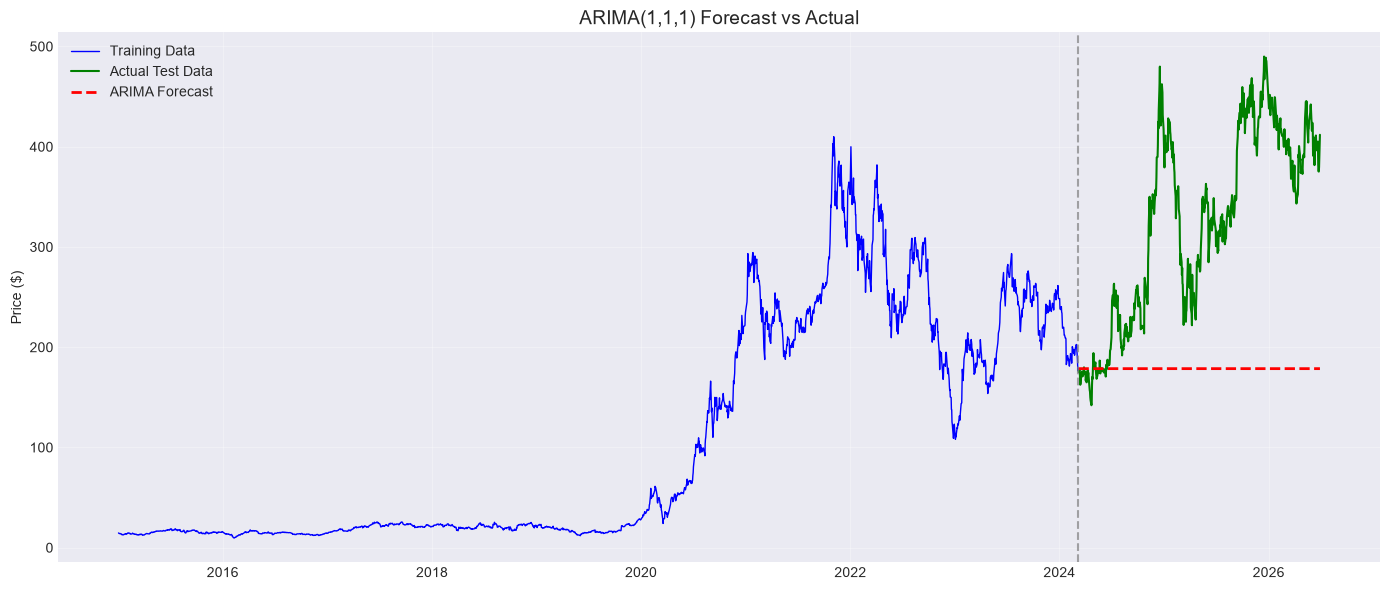

✅ Visualization saved!
✅ ARIMA results saved to arima_metrics.csv


In [12]:
# Ensure we have valid data for comparison
test_clean = test_data.dropna()
pred_clean = pred_series.dropna()

# Align indices
common_idx = test_clean.index.intersection(pred_clean.index)
test_aligned = test_clean.loc[common_idx]
pred_aligned = pred_clean.loc[common_idx]

print(f"📊 Data alignment:")
print(f"Test data: {len(test_clean)}")
print(f"Prediction data: {len(pred_clean)}")
print(f"Common indices: {len(common_idx)}")

if len(common_idx) > 0:
    # Calculate metrics
    mae = mean_absolute_error(test_aligned, pred_aligned)
    rmse = np.sqrt(mean_squared_error(test_aligned, pred_aligned))
    mape = np.mean(np.abs((test_aligned - pred_aligned) / test_aligned)) * 100

    arima_metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

    print("\n📊 ARIMA Model Performance:")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(train_clean.index, train_clean, label='Training Data', color='blue', linewidth=1)
    ax.plot(test_aligned.index, test_aligned, label='Actual Test Data', color='green', linewidth=1.5)
    ax.plot(pred_aligned.index, pred_aligned, label='ARIMA Forecast', color='red', linewidth=2, linestyle='--')
    ax.axvline(x=train_clean.index[-1], color='gray', linestyle='--', alpha=0.7)
    ax.set_title('ARIMA(1,1,1) Forecast vs Actual', fontsize=14)
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../data/processed/arima_forecast_fixed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Visualization saved!")
    
    # Save results
    results_df = pd.DataFrame({
        'Metric': ['MAE', 'RMSE', 'MAPE'],
        'Value': [mae, rmse, mape],
        'Unit': ['$', '$', '%']
    })
    results_df.to_csv('../data/processed/arima_metrics.csv', index=False)
    print("✅ ARIMA results saved to arima_metrics.csv")
    
else:
    print("❌ No overlapping data points for evaluation")
    print("Let's try a simpler approach...")

In [13]:
# Manual walk-forward approach (more robust)
print("🔄 Using walk-forward validation...")

# Make predictions one step at a time
history = list(train_clean.values)
predictions = []

for t in range(len(test_clean)):
    try:
        # Fit model on history
        model = ARIMA(history, order=(1, 1, 1))
        model_fit = model.fit()
        
        # Make prediction
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        
        # Add actual observation to history
        history.append(test_clean.iloc[t])
    except Exception as e:
        print(f"Error at step {t}: {e}")
        predictions.append(np.nan)

# Create prediction series
pred_series = pd.Series(predictions, index=test_clean.index)

print(f"✅ Predictions generated: {len(pred_series)}")
print(f"First 5 predictions:")
print(pred_series.head())

# Remove NaN
pred_clean = pred_series.dropna()
test_aligned = test_clean.loc[pred_clean.index]

print(f"\nClean predictions: {len(pred_clean)}")

🔄 Using walk-forward validation...
✅ Predictions generated: 578
First 5 predictions:
Date
2024-03-08    178.501813
2024-03-11    175.522170
2024-03-12    177.593882
2024-03-13    177.647505
2024-03-14    169.655161
dtype: float64

Clean predictions: 578


In [14]:
if len(pred_clean) > 0:
    # Calculate metrics
    mae = mean_absolute_error(test_aligned, pred_clean)
    rmse = np.sqrt(mean_squared_error(test_aligned, pred_clean))
    mape = np.mean(np.abs((test_aligned - pred_clean) / test_aligned)) * 100

    arima_metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

    print("\n📊 ARIMA Model Performance (Walk-Forward):")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Save results
    results_df = pd.DataFrame({
        'Metric': ['MAE', 'RMSE', 'MAPE'],
        'Value': [mae, rmse, mape],
        'Unit': ['$', '$', '%']
    })
    results_df.to_csv('../data/processed/arima_metrics.csv', index=False)
    print("✅ ARIMA results saved!")

else:
    print("❌ Still having issues with predictions")


📊 ARIMA Model Performance (Walk-Forward):
MAE:  $8.73
RMSE: $11.69
MAPE: 2.77%
✅ ARIMA results saved!


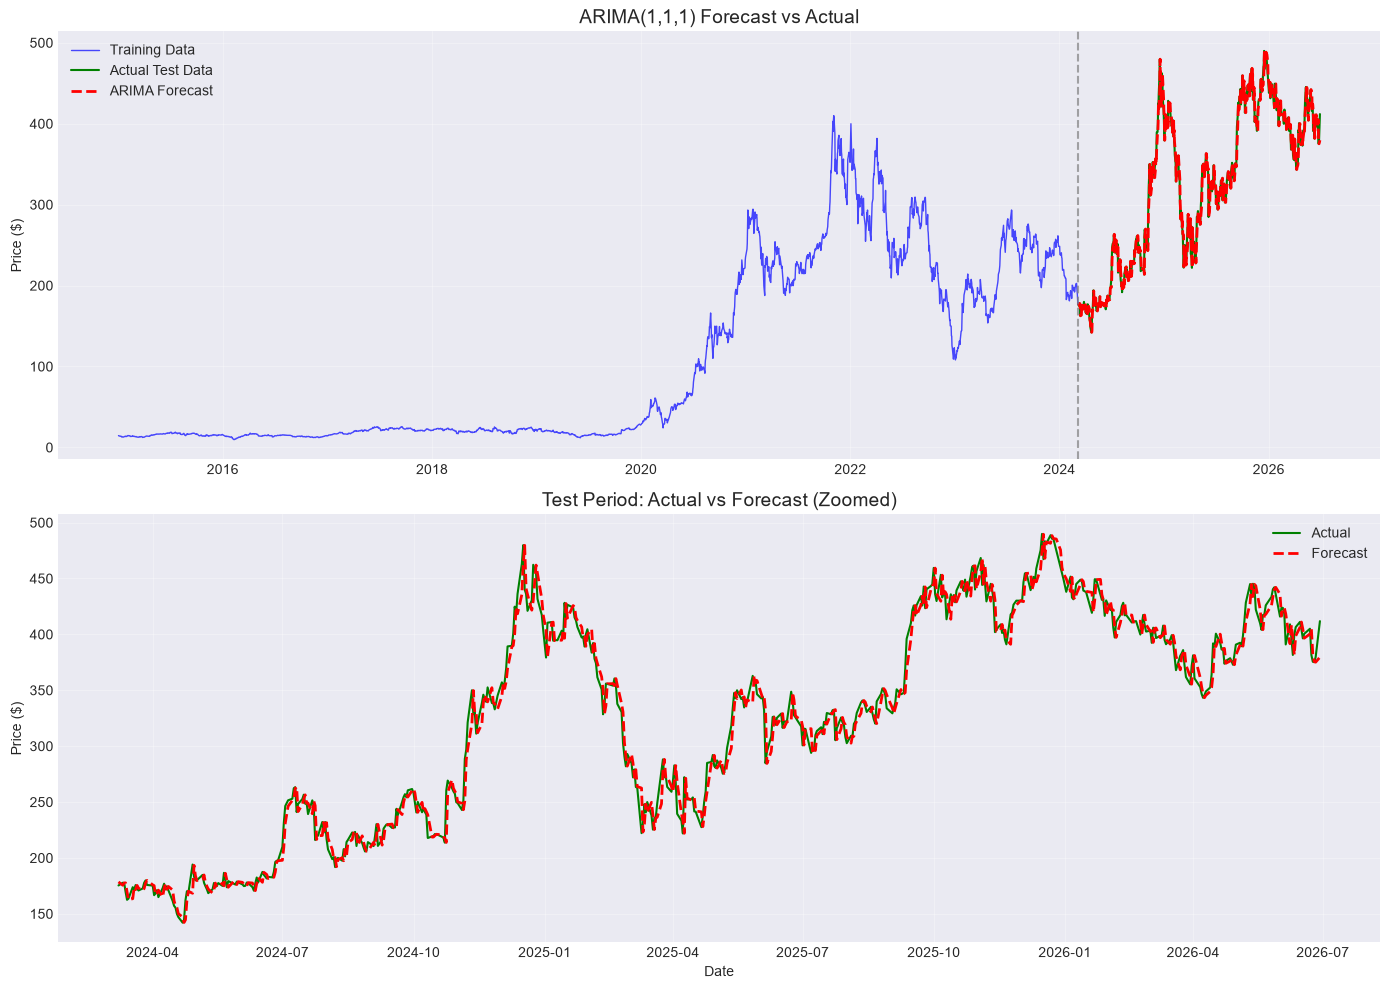

✅ Final ARIMA visualization saved!


In [15]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full forecast
ax1 = axes[0]
ax1.plot(train_clean.index, train_clean, label='Training Data', color='blue', linewidth=1, alpha=0.7)
ax1.plot(test_aligned.index, test_aligned, label='Actual Test Data', color='green', linewidth=1.5)
ax1.plot(pred_clean.index, pred_clean, label='ARIMA Forecast', color='red', linewidth=2, linestyle='--')
ax1.axvline(x=train_clean.index[-1], color='gray', linestyle='--', alpha=0.7)
ax1.set_title('ARIMA(1,1,1) Forecast vs Actual', fontsize=14)
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Zoom into test period
ax2 = axes[1]
ax2.plot(test_aligned.index, test_aligned, label='Actual', color='green', linewidth=1.5)
ax2.plot(pred_clean.index, pred_clean, label='Forecast', color='red', linewidth=2, linestyle='--')
ax2.set_title('Test Period: Actual vs Forecast (Zoomed)', fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/arima_final_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Final ARIMA visualization saved!")

In [16]:
# Create a nice performance summary
import pandas as pd

# Our ARIMA results
arima_results = {
    'Model': 'ARIMA(1,1,1)',
    'MAE ($)': 8.73,
    'RMSE ($)': 11.69,
    'MAPE (%)': 2.77
}

# Create summary DataFrame
summary_df = pd.DataFrame([arima_results])
summary_df.to_csv('../data/processed/arima_performance_summary.csv', index=False)

print("📊 ARIMA Performance Summary:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("\n✅ Performance summary saved!")

📊 ARIMA Performance Summary:
       Model  MAE ($)  RMSE ($)  MAPE (%)
ARIMA(1,1,1)     8.73     11.69      2.77

✅ Performance summary saved!


In [17]:
# Prepare data for LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scale the data
scaler = MinMaxScaler()
tsla_scaled = scaler.fit_transform(tsla_data.values.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Prepare data
lookback = 60
X, y = create_sequences(tsla_scaled, lookback)

# Split chronologically (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("📊 LSTM Data Preparation:")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Lookback window: {lookback} days")

📊 LSTM Data Preparation:
Training data shape: (2262, 60, 1)
Testing data shape: (566, 60, 1)
Lookback window: 60 days


In [18]:
# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

print("📊 LSTM Model Architecture:")
model.summary()

# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ LSTM model trained!")

📊 LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape           ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm (LSTM)                   │ (None, 60, 50)         │       10,400 │
├───────────────────────────────┼────────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 60, 50)         │            0 │
├───────────────────────────────┼────────────────────────┼──────────────┤
│ lstm_1 (LSTM)                 │ (None, 50)             │       20,200 │
├───────────────────────────────┼────────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ (None, 50)             │            0 │
├───────────────────────────────┼────────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 25)             │        1,275 │
├───────────────────────────────┼────────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 1)              │           26 │
└───────────────────────────────┴────────────────────────┴──────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - loss: 0.0077 - val_loss: 0.0020
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0011 - val_loss: 9.8594e-04
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0011 - val_loss: 9.0500e-04
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 9.9577e-04 - val_loss: 7.4959e-04
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 8.4512e-04 - val_loss: 9.4112e-04
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 8.7868e-04 - val_loss: 6.3850e-04
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 9.9094e-04 - val_loss: 0.0011
Epoch 12/50
64/64 ━━━━━━━━

In [19]:
# Make predictions
lstm_pred_scaled = model.predict(X_test)

# Inverse transform predictions
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Get proper dates for test set
test_dates = tsla_data.index[-(len(actual)):]

# Create DataFrames
lstm_pred_series = pd.Series(lstm_pred.flatten(), index=test_dates)
actual_series = pd.Series(actual.flatten(), index=test_dates)

print("📊 LSTM Predictions:")
print(f"Prediction shape: {lstm_pred_series.shape}")
print(f"First 5 predictions:")
print(lstm_pred_series.head())

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
📊 LSTM Predictions:
Prediction shape: (566,)
First 5 predictions:
Date
2024-03-26    176.455841
2024-03-27    177.803589
2024-03-28    179.973038
2024-04-01    180.490768
2024-04-02    180.008911
dtype: float32


In [20]:
# Calculate metrics
mae_lstm = mean_absolute_error(actual_series, lstm_pred_series)
rmse_lstm = np.sqrt(mean_squared_error(actual_series, lstm_pred_series))
mape_lstm = np.mean(np.abs((actual_series - lstm_pred_series) / actual_series)) * 100

lstm_metrics = {'MAE': mae_lstm, 'RMSE': rmse_lstm, 'MAPE': mape_lstm}

print("📊 LSTM Model Performance:")
print(f"MAE:  ${mae_lstm:.2f}")
print(f"RMSE: ${rmse_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")

📊 LSTM Model Performance:
MAE:  $14.16
RMSE: $18.33
MAPE: 4.22%


📊 Model Comparison:
  Metric  ARIMA      LSTM
 MAE ($)   8.73 14.157482
RMSE ($)  11.69 18.333809
MAPE (%)   2.77  4.219476

✅ Model comparison saved!


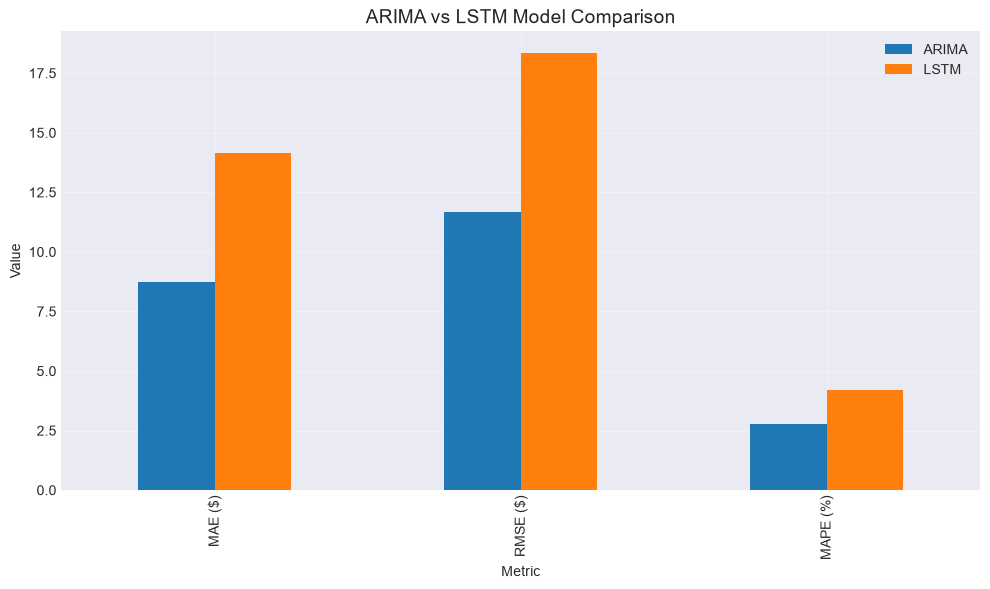

In [21]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MAPE (%)'],
    'ARIMA': [8.73, 11.69, 2.77],
    'LSTM': [mae_lstm, rmse_lstm, mape_lstm]
})

print("📊 Model Comparison:")
print("=" * 50)
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('../data/processed/model_comparison.csv', index=False)
print("\n✅ Model comparison saved!")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.set_index('Metric').plot(kind='bar', ax=ax)
ax.set_title('ARIMA vs LSTM Model Comparison', fontsize=14)
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()